# Working with SQLite databases

## Libraries and settings

In [70]:
# Libraries
import os
import sqlite3
import pandas as pd

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Show current working directory
print(os.getcwd())

/workspaces/scientific_programming/Week_03/exercises


## Create SQLite database

In [71]:
# Create db
conn = sqlite3.connect('./data/online_store.db')

# Close connection to db
conn.close()

## Create table 'Customers' and include data

In [72]:
# Open connection to db
conn = sqlite3.connect('./data/online_store.db')

# Create table and define variables and data types
conn.execute('''CREATE TABLE IF NOT EXISTS Customers
             (CustomerID INT PRIMARY KEY     NOT NULL,
              CustomerName           TEXT    NOT NULL,
              ContactName            TEXT    NOT NULL,
              Address            CHAR(100),
              City               CHAR(100), 
              PostalCode         CHAR(50),
              Country            CHAR(50));''')

# Import data
df_cust = pd.read_excel('./data/customers.xlsx', sheet_name='sheet01')

# Write data to the data base table named 'COMPANY'
df_cust.to_sql('Customers', conn, if_exists='replace')

# Commit the changes to the table
conn.commit()

# Close connection to db
conn.close()


## Create table 'Orders' and include data

In [73]:
# Open connection to db
conn = sqlite3.connect('./data/online_store.db')

# Create table and define variables and data types
conn.execute('''CREATE TABLE IF NOT EXISTS Orders
             (OrderID INT PRIMARY KEY   NOT NULL,
              CustomerID         INT    NOT NULL,
              EmployeeID	     INT    NOT NULL,
              OrderDate	         CHAR(100),
              ShipperID          INT);''')

# Import data
df_cust = pd.read_excel('./data/orders.xlsx', sheet_name='sheet01')

# Write data to the data base table named 'COMPANY'
df_cust.to_sql('Orders', conn, if_exists='replace')

# Commit the changes to the table
conn.commit()

# Close connection to db
conn.close()

### Query the database using SQL and write result to a pandas data frame

In [74]:
# Connection to db
conn = sqlite3.connect("./data/online_store.db")

# SQL query
df_sub = pd.read_sql("""SELECT
                        T1.CustomerID, 
                        T1.ContactName, 
                        T1.Address, 
                        T1.City,
                        T1.PostalCode, 
                        T1.Country, 
                        T2.OrderID, 
                        T2.OrderDate
                        FROM Customers AS T1
                        LEFT JOIN Orders AS T2
                        ON T1.CustomerID = T2.CustomerID
                        WHERE T1.Country = "France"
                        AND T1.City IN ("Nantes", "Paris", "Toulouse")
                        ORDER BY T1.ContactName""",
                     con=conn)
 
# Close connection to db
conn.close()

# Show result
df_sub


,CustomerID,ContactName,Address,City,PostalCode,Country,OrderID,OrderDate
0,41,Annette Roulet,1 rue Alsace-Lorraine,Toulouse,31000,France,10350.0,1996-11-11 00:00:00
1,41,Annette Roulet,1 rue Alsace-Lorraine,Toulouse,31000,France,10358.0,1996-11-20 00:00:00
2,41,Annette Roulet,1 rue Alsace-Lorraine,Toulouse,31000,France,10371.0,1996-12-03 00:00:00
3,41,Annette Roulet,1 rue Alsace-Lorraine,Toulouse,31000,France,10413.0,1997-01-14 00:00:00
4,41,Annette Roulet,1 rue Alsace-Lorraine,Toulouse,31000,France,10425.0,1997-01-24 00:00:00
5,26,Carine Schmitt,"54, rue Royale",Nantes,44000,France,NaN,None
6,74,Dominique Perrier,"25, rue Lauriston",Paris,75016,France,NaN,None
7,18,Janine Labrune,"67, rue des Cinquante Otages",Nantes,44000,France,10311.0,1996-09-20 00:00:00
8,57,Marie Bertrand,"265, boulevard Charonne",Paris,75012,France,NaN,None


Struktur der Tabelle 'Sales':
   cid           name       type  notnull dflt_value  pk
0    0          index    INTEGER        0       None   0
1    1         saleid       TEXT        0       None   0
2    2          carid       TEXT        0       None   0
3    3     customerid       TEXT        0       None   0
4    4       saledate  TIMESTAMP        0       None   0
5    5      saleprice       REAL        0       None   0
6    6  salespersonid       TEXT        0       None   0
Struktur des DataFrames:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   saleprice  2500 non-null   float64
dtypes: float64(1)
memory usage: 19.7 KB
None
Ausgewählte Preise >= 10.000 USD:
   saleprice
0   34751.87
1   26772.89
2   30015.32
3   43179.54
4   19002.08


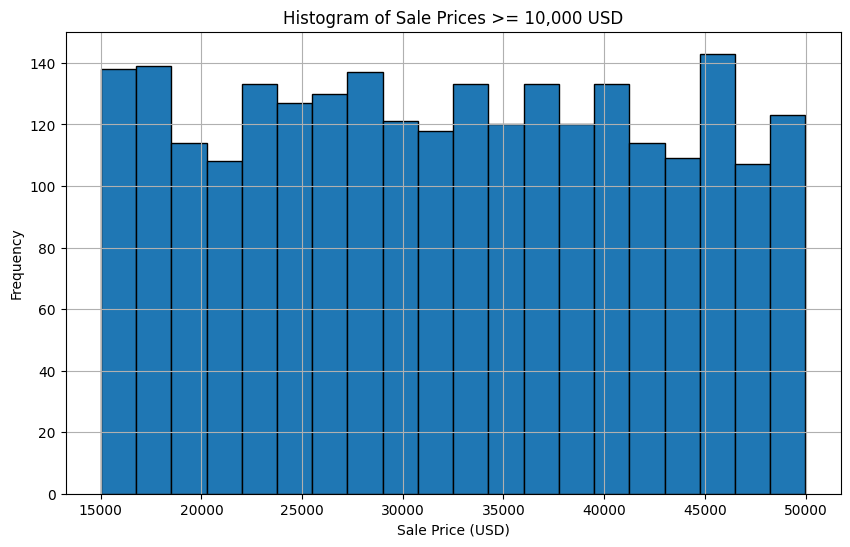

In [75]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import os

# Pfad zur SQLite-Datenbank
db_path = './data/car_dealer_data.db'

# Erstellen einer Verbindung zur SQLite-Datenbank
conn = sqlite3.connect(db_path)

# Überprüfen der Struktur der Tabelle 'Sales'
table_info_query = "PRAGMA table_info(Sales)"
table_info = pd.read_sql_query(table_info_query, conn)
print("Struktur der Tabelle 'Sales':")
print(table_info)

# Schreiben einer SQL-Abfrage, um Preise >= 10.000 USD auszuwählen
query = "SELECT saleprice FROM Sales WHERE saleprice >= 10000"

# Ausführen der Abfrage und Speichern des Ergebnisses in einem Pandas DataFrame
df = pd.read_sql_query(query, conn)

# Anzeigen der Struktur des DataFrames
print("Struktur des DataFrames:")
print(df.info())

# Anzeigen der ersten Zeilen des DataFrames
print("Ausgewählte Preise >= 10.000 USD:")
print(df.head())

# Überprüfen, ob die Spalte 'saleprice' im DataFrame vorhanden ist
if 'saleprice' in df.columns:
    # Erstellen des Verzeichnisses, falls es nicht existiert
    os.makedirs('./data', exist_ok=True)
    
    # Erstellen eines Histogramms der ausgewählten Preise
    plt.figure(figsize=(10, 6))
    plt.hist(df['saleprice'], bins=20, edgecolor='black')
    plt.title('Histogram of Sale Prices >= 10,000 USD')
    plt.xlabel('Sale Price (USD)')
    plt.ylabel('Frequency')
    plt.grid(True)

    # Speichern des Histogramms in einer Datei
    plt.savefig('./data/histogram.png')

    # Anzeigen des Histogramms
    plt.show()
else:
    print("Die Spalte 'saleprice' ist im DataFrame nicht vorhanden.")

# Schließen der Verbindung zur Datenbank
conn.close()

### Jupyter notebook --footer info-- (please always provide this at the end of each notebook)

In [76]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Linux | 6.5.0-1025-azure
Datetime: 2025-03-06 15:15:14
Python Version: 3.11.11
-----------------------------------
